<div style="background:#15294D;padding:24px 32px;border-radius:12px;margin-bottom:8px">
<h1 style="color:white;margin:0;font-family:Arial;font-size:28px">Guess What? ✏️ Air Pictionary</h1>
<p style="color:#6FAF22;margin:8px 0 4px 0;font-size:15px;font-family:Arial;font-weight:bold">Computer Vision Bootcamp | Final Project</p>
<p style="color:#A0C4FF;margin:0;font-size:13px;font-family:Arial">Draw in the air with your finger. The AI guesses what you drew, live.</p>
</div>

<div style="background:#F0FDF4;border-left:5px solid #6FAF22;padding:12px 16px;border-radius:6px;margin:10px 0"><b style="color:#15294D">The idea:</b> a Pictionary game where you draw <b>in the air</b> in front of the camera.
The computer tracks your hand, turns your movement into a drawing, and a CNN guesses what it is while you draw.<br><br>
<b style="color:#15294D">The full pipeline:</b>
<pre style="background:white;padding:10px;border-radius:6px;margin:8px 0">
Quick, Draw! data → Explore → Prepare → CNN → Train → Evaluate → Save
                                                                    ↓
           Camera → Hand tracking → Air drawing → 28×28 image → CNN guess (live)
</pre>
<b style="color:#6FAF22">Part 1:</b> train a CNN that recognizes 20 doodles (steps 1 to 10).<br>
<b style="color:#0D9488">Part 2:</b> draw in the air with the camera and get live guesses (step 11).</div>

<div style="background:#F3F6FA;padding:12px 16px;border-radius:6px;margin:10px 0">
<b>Results so far (version 1, 5 classes)</b>. Version 2 has 20 classes: retrain and the new numbers will appear in the outputs.
<table>
<tr><td>Classes</td><td>sun, fish, house, star, umbrella</td></tr>
<tr><td>Training data</td><td>25,000 drawings (5,000 per class) from Google Quick, Draw!</td></tr>
<tr><td>Model</td><td>small CNN, 240,901 parameters (~941 KB)</td></tr>
<tr><td>Validation accuracy</td><td><b>97.6%</b> (best epoch 6)</td></tr>
<tr><td>Test accuracy</td><td><b>97.0%</b> (2,425 / 2,500)</td></tr>
<tr><td>Confidence threshold</td><td>0.7 → answers 98.0% of drawings, 98.2% correct</td></tr>
</table>
</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0"><b>How to run:</b> Runtime → Change runtime type → <b>T4 GPU</b>. Run the cells from top to bottom.<br>
<b>Already trained?</b> Skip to <b>Step 11</b>: it loads the saved model from Google Drive, no retraining needed.</div>

---
# PART 1: Train the Doodle Recognizer

## Step 1: Download the data
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: <b style='color:#6FAF22'>[ Data ]</b> &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0"><b>Dataset:</b> <a href="https://github.com/googlecreativelab/quickdraw-dataset">Google Quick, Draw!</a>: over 50 million doodles drawn by real people in a 20-second online game, in 345 categories.<br><br>
<b>Format we use:</b> <code>numpy_bitmap</code>. One <code>.npy</code> file per category. Each row is one drawing: a 28 × 28 grayscale image flattened into <b>784 numbers</b>.
<code>0</code> = empty background, <code>255</code> = the drawn line.<br><br>
<b>Our 20 classes:</b> version 1 had 5 (sun, fish, house, star, umbrella). Version 2 adds 15: apple, tree, car, cat, cloud, eye, key, moon, mushroom, envelope, lightning, smiley face, rainbow, ladder, ice cream.<br><b>How we chose them:</b> easy to draw in the air in a few strokes, and visually different. We avoided shapes that look like sun or star (flower, snowflake), because sun ↔ star was already our biggest confusion. The full list of 345 classes: <a href='https://raw.githubusercontent.com/googlecreativelab/quickdraw-dataset/master/categories.txt'>categories.txt</a>.<br><b>Download:</b> 20 files × ~100+ MB, about 1 to 3 minutes in Colab.</div>

**What you will see:** one line per class saying it was downloaded (about 100+ MB each).

In [1]:
# ============================================================
# STEP 1 · Download the Quick, Draw! data
# ============================================================
# One .npy file per class from Google's servers (~100+ MB each).
# Inside: one row per drawing = 784 numbers (a 28x28 image, flattened).
import os, urllib.request

CLASSES = [
    # version 1: the first 5 shapes
    "sun", "fish", "house", "star", "umbrella",
    # version 2: 15 new shapes, easy to draw in the air and different from each other
    "apple", "tree", "car", "cat", "cloud",
    "eye", "key", "moon", "mushroom", "envelope",
    "lightning", "smiley face", "rainbow", "ladder", "ice cream",
]
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/"

for name in CLASSES:
    path = f"{name}.npy"
    if os.path.exists(path):                                   # don't download twice
        print(f"{name:12s} already downloaded")
        continue
    urllib.request.urlretrieve(BASE_URL + name.replace(" ", "%20") + ".npy", path)   # spaces in names -> %20
    print(f"{name:12s} downloaded ({os.path.getsize(path) / 1e6:.0f} MB)")

print(f"\n{len(CLASSES)} classes ready")

sun          downloaded (105 MB)
fish         downloaded (105 MB)
house        downloaded (106 MB)
star         downloaded (108 MB)
umbrella     downloaded (97 MB)
apple        downloaded (113 MB)
tree         downloaded (113 MB)
car          downloaded (143 MB)
cat          downloaded (97 MB)
cloud        downloaded (94 MB)
eye          downloaded (99 MB)
key          downloaded (126 MB)
moon         downloaded (95 MB)
mushroom     downloaded (111 MB)
envelope     downloaded (106 MB)
lightning    downloaded (119 MB)
smiley face  downloaded (98 MB)
rainbow      downloaded (99 MB)
ladder       downloaded (98 MB)
ice cream    downloaded (97 MB)

20 classes ready


## Step 2: Keep 5,000 drawings per class and save to Drive
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: <b style='color:#6FAF22'>[ Data ]</b> &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0"><b>Why only 5,000?</b> Each file has over 100,000 drawings. 20 classes × 5,000 = <b>100,000 drawings</b>, which is plenty for simple shapes.
More data would only make training slower for very little gain.<br><br>
<b>X</b> = the drawings, shape <code>(100000, 784)</code>. <b>y</b> = the labels, shape <code>(100000,)</code>: 0 = sun, 1 = fish, … 19 = ice cream (same order as <code>CLASSES</code>).<br><b>New:</b> <code>mmap_mode="r"</code> reads only the 5,000 rows we need from each file, so memory stays low even with 20 big files.<br><br>
<b>Why save to Drive?</b> Colab deletes files when the session resets. The small <code>.npz</code> file in Drive means we never download the big files again.</div>

In [2]:
# ============================================================
# STEP 2 · Keep 5,000 drawings per class and save them to Google Drive
# ============================================================
import numpy as np
from google.colab import drive

drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/air_pictionary"           # our project folder in Drive
os.makedirs(SAVE_DIR, exist_ok=True)

N = 5000                                                      # drawings per class

X, y = [], []
for label, name in enumerate(CLASSES):                        # label = 0, 1, 2, ... (same order as CLASSES)
    # mmap_mode="r" reads only the rows we keep, instead of loading the whole big file into memory
    data = np.array(np.load(f"{name}.npy", mmap_mode="r")[:N])
    X.append(data)
    y.append(np.full(len(data), label))                       # the same label for every drawing of this class
    print(f"{label:2d} {name:12s} {data.shape}")

X = np.concatenate(X)                                         # (num_classes * 5000, 784): all drawings
y = np.concatenate(y)                                         # (num_classes * 5000,):     all labels
print("X:", X.shape, "| y:", y.shape)

# One small compressed file, so next time we can skip the downloads:
#   data = np.load(f"{SAVE_DIR}/quickdraw_{len(CLASSES)}classes.npz");  X, y = data["X"], data["y"]
np.savez_compressed(f"{SAVE_DIR}/quickdraw_{len(CLASSES)}classes.npz", X=X, y=y, classes=np.array(CLASSES))
print("Saved to", SAVE_DIR)

Mounted at /content/drive
 0 sun          (5000, 784)
 1 fish         (5000, 784)
 2 house        (5000, 784)
 3 star         (5000, 784)
 4 umbrella     (5000, 784)
 5 apple        (5000, 784)
 6 tree         (5000, 784)
 7 car          (5000, 784)
 8 cat          (5000, 784)
 9 cloud        (5000, 784)
10 eye          (5000, 784)
11 key          (5000, 784)
12 moon         (5000, 784)
13 mushroom     (5000, 784)
14 envelope     (5000, 784)
15 lightning    (5000, 784)
16 smiley face  (5000, 784)
17 rainbow      (5000, 784)
18 ladder       (5000, 784)
19 ice cream    (5000, 784)
X: (100000, 784) | y: (100000,)
Saved to /content/drive/MyDrive/air_pictionary


## Step 3: Look at the data
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; <b style='color:#6FAF22'>[ Explore ]</b> &rarr; Prepare &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0">Always look at your data before training. Real people drew these in seconds, so expect messy drawings.<br>
<b>What you will see:</b> one row per class, 8 random drawings each. Run it again for different examples.</div>

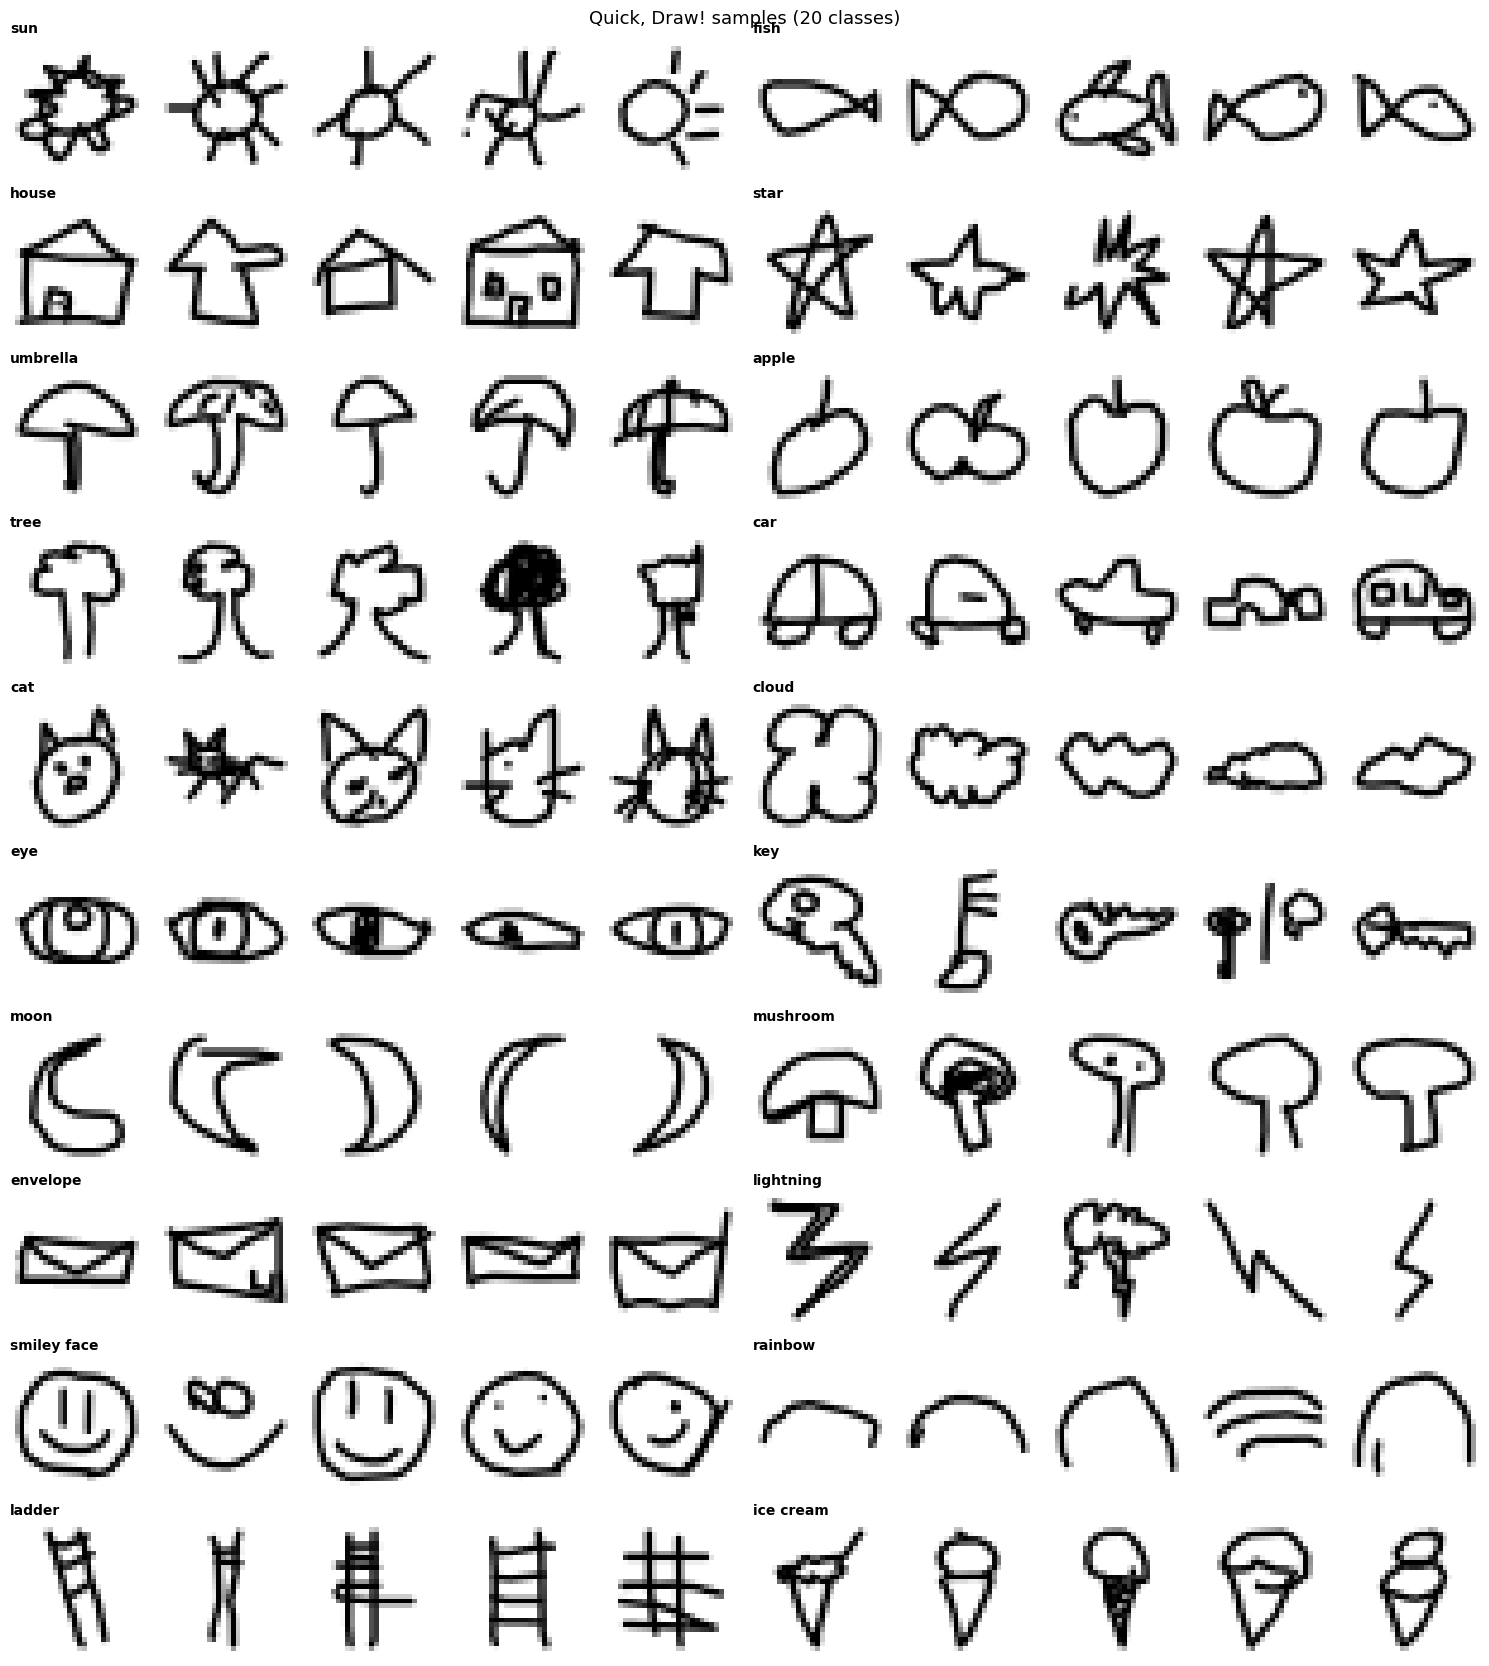

In [3]:
# ============================================================
# STEP 3 · Look at the data: 5 random drawings per class, 2 classes per row
# ============================================================
import matplotlib.pyplot as plt

n_show, per_row = 5, 2
rows = int(np.ceil(len(CLASSES) / per_row))
fig, axes = plt.subplots(rows, n_show * per_row, figsize=(15, 1.7 * rows))
for ax in axes.flat:
    ax.axis("off")
for c, name in enumerate(CLASSES):
    r, start = c // per_row, (c % per_row) * n_show                      # where this class goes in the grid
    idx = np.random.choice(np.where(y == c)[0], n_show, replace=False)   # random drawings of this class
    for k, i in enumerate(idx):
        axes[r, start + k].imshow(X[i].reshape(28, 28), cmap="gray_r")   # 784 numbers -> 28x28 image
    axes[r, start].set_title(name, loc="left", fontsize=10, fontweight="bold")
plt.suptitle(f"Quick, Draw! samples ({len(CLASSES)} classes)", fontsize=13)
plt.tight_layout()
plt.show()

## Step 4: Prepare the data and split it
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; <b style='color:#6FAF22'>[ Prepare ]</b> &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0">Three things the CNN needs:<br>
1. <b>Scale</b> pixels from 0..255 to <b>0..1</b>: neural networks learn better with small numbers.<br>
2. <b>Reshape</b> each row of 784 numbers into an image of <b>28 × 28 × 1</b> (1 = one grayscale channel).<br>
3. <b>Split</b> into three groups:
<ul>
<li><b>Train (80%, 80,000):</b> the model learns from these.</li>
<li><b>Validation (10%, 10,000):</b> checked after every epoch, to see if the model really learns or just memorizes.</li>
<li><b>Test (10%, 10,000):</b> hidden until the end, for the final honest score.</li>
</ul>
<code>stratify=y</code> keeps the same class balance in every split. <code>random_state=42</code> makes the split the same every run (reproducible).</div>

In [4]:
# ============================================================
# STEP 4 · Prepare the data and split it 80 / 10 / 10
# ============================================================
from sklearn.model_selection import train_test_split

# (N, 784) -> (N, 28, 28, 1), and pixels 0..255 -> 0..1
X_prep = X.reshape(-1, 28, 28, 1).astype("float32") / 255.0

# First split: 80% train, 20% "rest". Second split: the rest -> 10% validation, 10% test.
# stratify keeps the class balance; random_state makes the split the same every run.
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X_prep, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.5, stratify=y_tmp, random_state=42)

print("train:", X_train.shape)
print("val:  ", X_val.shape)
print("test: ", X_test.shape)

train: (80000, 28, 28, 1)
val:   (10000, 28, 28, 1)
test:  (10000, 28, 28, 1)


**Is the data balanced?** If one class had many more drawings, the model could guess it more often and still look accurate.
We took exactly 5,000 per class and used `stratify`, so every split should be perfectly balanced.

**What you will see:** 4,000 for every class in train, and 500 for every class in validation and test.

In [5]:
# Count the drawings of each class in every split (same order as CLASSES)
print("train:", np.bincount(y_train))
print("val:  ", np.bincount(y_val))
print("test: ", np.bincount(y_test))

train: [4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000 4000
 4000 4000 4000 4000 4000 4000]
val:   [500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500]
test:  [500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500 500
 500 500]


## Step 5: Build the CNN
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; <b style='color:#6FAF22'>[ CNN ]</b> &rarr; Train &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#F0FDF4;border-left:5px solid #6FAF22;padding:12px 16px;border-radius:6px;margin:10px 0"><b>Data augmentation (first 3 layers).</b> Small random changes to each drawing, <b>only during training</b>:
<ul>
<li><code>RandomRotation(0.08)</code>: tilt by up to ±29°</li>
<li><code>RandomTranslation(0.1, 0.1)</code>: shift by up to 3 pixels</li>
<li><code>RandomZoom(0.1)</code>: bigger or smaller by up to 10%</li>
</ul>
<b>Why:</b> air drawings will be shakier, tilted, and off-center compared to Quick, Draw! drawings. Augmentation teaches the model that a tilted sun is still a sun.
It also fights overfitting, because the model never sees the exact same image twice. These layers switch off automatically when predicting.</div>

**How a drawing flows through the model:** the image gets **smaller** but **deeper**. The model trades pixel detail for meaning.

| Layer | Output shape | What it does |
|---|---|---|
| Input + augmentation | 28 × 28 × 1 | One grayscale drawing, randomly changed during training |
| Conv2D 32 + MaxPool | 14 × 14 × 32 | 32 filters find simple strokes (edges, curves) |
| Conv2D 64 + MaxPool | 7 × 7 × 64 | Combine strokes into parts (corners, circles) |
| Conv2D 128 + MaxPool | 3 × 3 × 128 | Combine parts into shapes (rays, roof, tail) |
| Flatten + Dropout(0.4) | 1,152 | Unroll to a list; dropout switches off 40% of neurons while training, against memorizing |
| Dense 128 | 128 | Combine all features |
| Dense 20 + softmax | 20 | One probability per class, adding up to 100% |

**Total: 242,836 parameters (~949 KB)** with 20 classes (only the last layer grows). Small on purpose: it trains in seconds and runs in real time in the game.

In [6]:
# ============================================================
# STEP 5 · Build the CNN
# ============================================================
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Input((28, 28, 1)),                                # one 28x28 grayscale drawing

    # Data augmentation: random changes, ONLY during training (off when predicting)
    layers.RandomRotation(0.08),                              # tilt up to +-29 degrees
    layers.RandomTranslation(0.1, 0.1),                       # shift up to ~3 pixels
    layers.RandomZoom(0.1),                                   # zoom in/out up to 10%

    # Feature extraction: simple strokes -> parts -> whole shapes
    layers.Conv2D(32, 3, padding="same", activation="relu"),  # 28x28x32
    layers.MaxPooling2D(),                                    # 14x14x32
    layers.Conv2D(64, 3, padding="same", activation="relu"),  # 14x14x64
    layers.MaxPooling2D(),                                    # 7x7x64
    layers.Conv2D(128, 3, padding="same", activation="relu"), # 7x7x128
    layers.MaxPooling2D(),                                    # 3x3x128

    # Decision: features -> one of the 5 classes
    layers.Flatten(),                                         # 3*3*128 = 1152 numbers
    layers.Dropout(0.4),                                      # switch off 40% of neurons while training (anti-memorizing)
    layers.Dense(128, activation="relu"),
    layers.Dense(len(CLASSES), activation="softmax"),         # 5 probabilities that add up to 1
])

model.compile(optimizer="adam",                              # adjusts the weights after each batch
              loss="sparse_categorical_crossentropy",         # for integer labels (0..4)
              metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_rotation                 │ (None, 28, 28, 1)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 28, 28, 1)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,836 (948.58 KB)

 Trainable params: 242,836 (948.58 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the model
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; <b style='color:#6FAF22'>[ Train ]</b> &rarr; Evaluate &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0"><b>Epoch</b> = one full pass over the 80,000 training drawings. <b>batch_size=128</b>: the model looks at 128 drawings, measures its mistakes, adjusts its weights, then the next 128. So one epoch = 625 updates (about 4× longer than version 1).<br><br>
<b>EarlyStopping</b> watches <code>val_accuracy</code> after each epoch:
<ul>
<li><code>patience=3</code>: if it doesn't beat its best score for 3 epochs in a row, training stops. (Validation accuracy wobbles a bit by chance, so we give it 3 chances before stopping.)</li>
<li><code>restore_best_weights=True</code>: we keep the <b>best</b> version, not the last one.</li>
</ul>
<code>epochs=20</code> is only the maximum. Too few epochs = underfitting, too many = overfitting. EarlyStopping decides for us.</div>

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:12px 16px;border-radius:6px;margin:10px 0"><b style='color:#E8A020'>What we found (version 1, 5 classes):</b><br>Training stopped at epoch 9. The best <code>val_accuracy</code> was <b>97.64% at epoch 6</b>, then 3 epochs without improvement, so the model went back to epoch 6.<br>
Validation accuracy (~97%) is <i>higher</i> than training accuracy (~95%). That's normal here: during training the model sees augmented drawings with dropout on (harder),
during validation it sees clean drawings at full power. It also shows the model is <b>not overfitting</b>.</div>

In [7]:
# ============================================================
# STEP 6 · Train, and stop automatically when validation stops improving
# ============================================================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",       # watch accuracy on drawings the model doesn't train on
    patience=3,                   # stop after 3 epochs without a new best
    restore_best_weights=True)    # go back to the best epoch, not the last one

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,                    # maximum; EarlyStopping usually stops earlier
    batch_size=128,               # 80,000 / 128 = 625 updates per epoch
    callbacks=[early_stop],
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6363 - loss: 1.2185 - val_accuracy: 0.8695 - val_loss: 0.4878
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8129 - loss: 0.6537 - val_accuracy: 0.8977 - val_loss: 0.4240
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8463 - loss: 0.5427 - val_accuracy: 0.9119 - val_loss: 0.3683
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.8617 - loss: 0.4877 - val_accuracy: 0.9166 - val_loss: 0.3421
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8740 - loss: 0.4427 - val_accuracy: 0.9190 - val_loss: 0.3407
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8824 - loss: 0.4135 - val_accuracy: 0.9267 - val_loss: 0.3133
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8880 - loss: 0.3924 - val_accuracy: 0.9319 - val_loss: 0.2943
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8928 - loss: 0.3765 - val_accuracy:

**Training curves.** Both lines should rise together. If training keeps rising while validation goes down, the model is memorizing (overfitting).

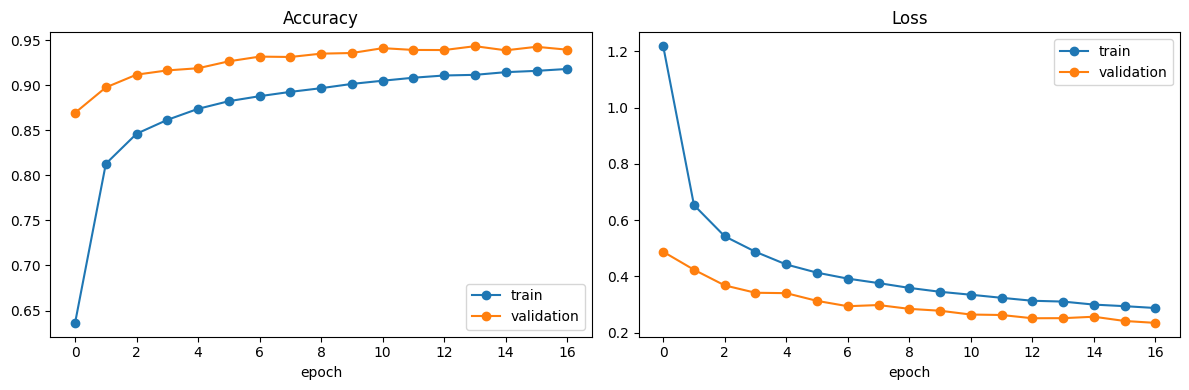

Best epoch: 14  |  val_accuracy = 94.35%


In [8]:
# Training curves: accuracy and loss for every epoch
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history["accuracy"], marker="o", label="train")
ax[0].plot(history.history["val_accuracy"], marker="o", label="validation")
ax[0].set_title("Accuracy"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history.history["loss"], marker="o", label="train")
ax[1].plot(history.history["val_loss"], marker="o", label="validation")
ax[1].set_title("Loss"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.show()

best = int(np.argmax(history.history["val_accuracy"]))
print(f"Best epoch: {best + 1}  |  val_accuracy = {history.history['val_accuracy'][best] * 100:.2f}%")

## Step 7: Evaluate on the test set
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; <b style='color:#6FAF22'>[ Evaluate ]</b> &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0">The test set (10,000 drawings) was never used during training or for choosing the model. This is the honest final score.<br><br>
<b>How to read the confusion matrix:</b> each <b>row</b> is the true class, each <b>column</b> is the prediction. The diagonal = correct. Any big number off the diagonal = two classes the model confuses. With 20 classes, the cell also prints the <b>most confused pairs</b>, which is easier to read.</div>

In [9]:
# ============================================================
# STEP 7 · Final score on the test set (never seen before)
# ============================================================
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")

Test accuracy: 93.96%


              precision    recall  f1-score   support

         sun       0.99      0.94      0.96       500
        fish       0.91      0.93      0.92       500
       house       0.95      0.97      0.96       500
        star       0.91      0.95      0.93       500
    umbrella       0.95      0.97      0.96       500
       apple       0.97      0.95      0.96       500
        tree       0.92      0.92      0.92       500
         car       0.92      0.96      0.94       500
         cat       0.88      0.92      0.90       500
       cloud       0.97      0.93      0.95       500
         eye       0.95      0.93      0.94       500
         key       0.90      0.90      0.90       500
        moon       0.86      0.94      0.90       500
    mushroom       0.94      0.88      0.91       500
    envelope       0.99      0.97      0.98       500
   lightning       0.93      0.90      0.91       500
 smiley face       0.96      0.92      0.94       500
     rainbow       0.99    

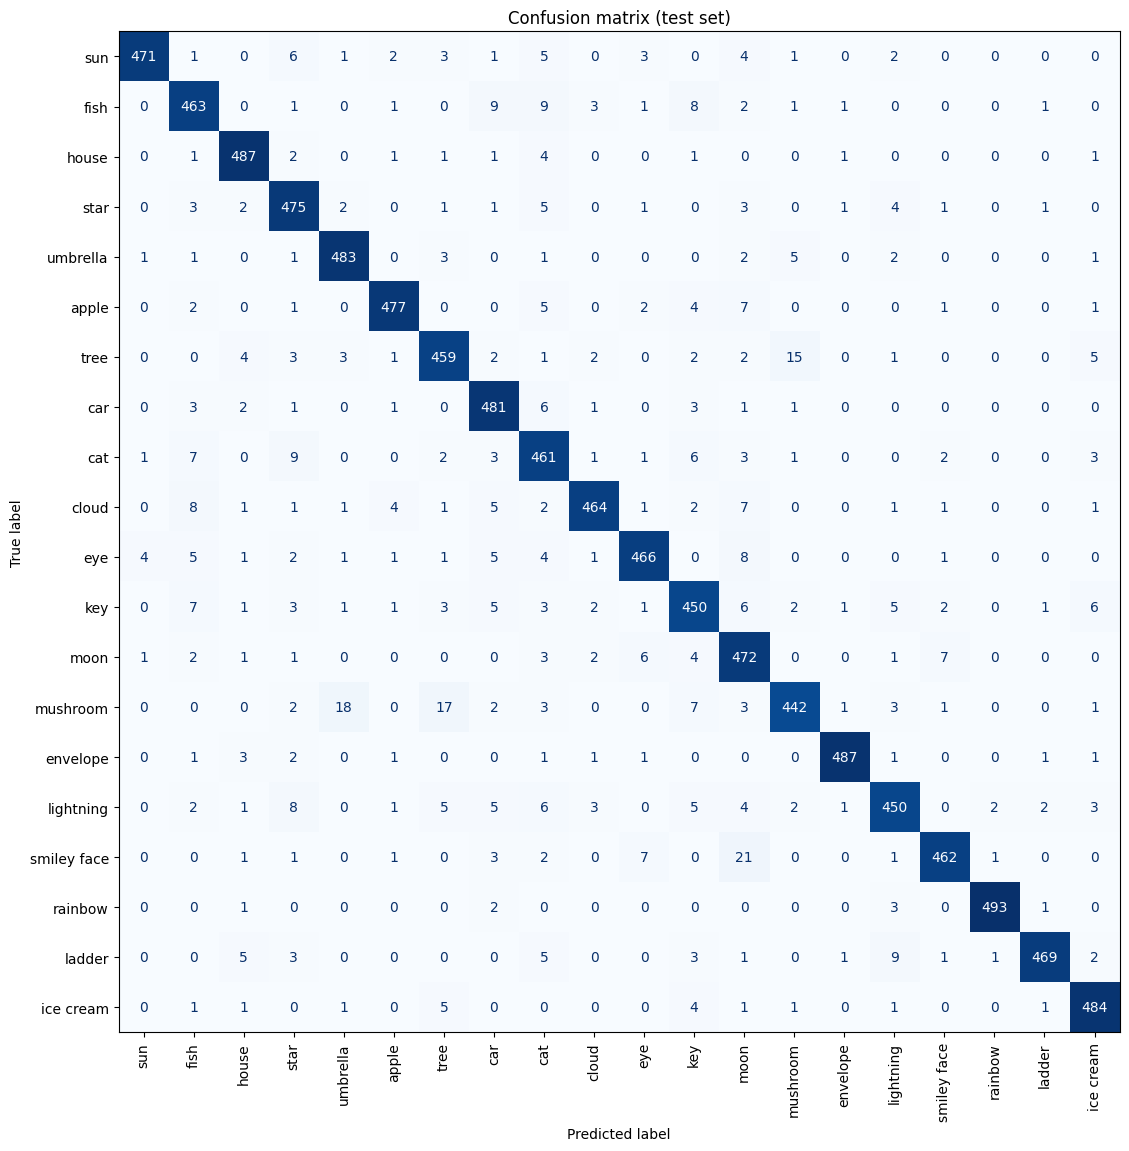

Most confused pairs (true -> predicted):
  smiley face  -> moon         21 times
  mushroom     -> umbrella     18 times
  mushroom     -> tree         17 times
  tree         -> mushroom     15 times
  fish         -> cat          9 times
  fish         -> car          9 times
  cat          -> star         9 times
  ladder       -> lightning    9 times


In [10]:
# Per-class report + confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

probs  = model.predict(X_test, verbose=0)     # a probability for each class
y_pred = probs.argmax(axis=1)                 # the class with the highest probability
conf   = probs.max(axis=1)                    # how confident the model is (used in Step 9)

print(classification_report(y_test, y_pred, target_names=CLASSES))

cm = confusion_matrix(y_test, y_pred)         # rows = true class, columns = predicted class
fig, ax = plt.subplots(figsize=(13, 13))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=90)
plt.title("Confusion matrix (test set)")
plt.show()

# With many classes the matrix is hard to read, so list the biggest confusions
off = cm.copy(); np.fill_diagonal(off, 0)                     # keep only the mistakes
print("Most confused pairs (true -> predicted):")
for flat in np.argsort(off.ravel())[::-1][:8]:
    t, p = np.unravel_index(flat, off.shape)
    print(f"  {CLASSES[t]:12s} -> {CLASSES[p]:12s} {off[t, p]} times")

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:12px 16px;border-radius:6px;margin:10px 0"><b style='color:#E8A020'>What we found (version 1, 5 classes):</b><br>Test accuracy: <b>97.0%</b> (2,425 / 2,500), the same as validation, so the model generalizes well.
<table>
<tr><th>Class</th><th>Correct (out of 500)</th></tr>
<tr><td>umbrella</td><td>492 (98.4%)</td></tr>
<tr><td>fish</td><td>490 (98.0%)</td></tr>
<tr><td>house</td><td>487 (97.4%)</td></tr>
<tr><td>sun</td><td>485 (97.0%)</td></tr>
<tr><td><b>star</b></td><td><b>471 (94.2%)</b>, the weakest</td></tr>
</table>
<ul>
<li><b>Star is the hardest class.</b> It gets confused with fish (11), sun (10) and house (6).</li>
<li><b>Sun ↔ star confusion goes both ways</b> (10 and 8): both are a center shape with points around it.</li>
<li><b>Fish is the model's "fallback" guess:</b> 30 wrong predictions landed on fish. When a drawing is messy, the model tends to say fish.</li>
</ul></div>

## Step 8: Look at the mistakes
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; <b style='color:#6FAF22'>[ Evaluate ]</b> &rarr; Save &rarr; Air Drawing</div>

Accuracy is one number. Looking at the actual wrong drawings tells us **why** the model fails.

**What you will see:** 12 random wrong predictions, with the true label and the model's guess.

604 wrong out of 10000


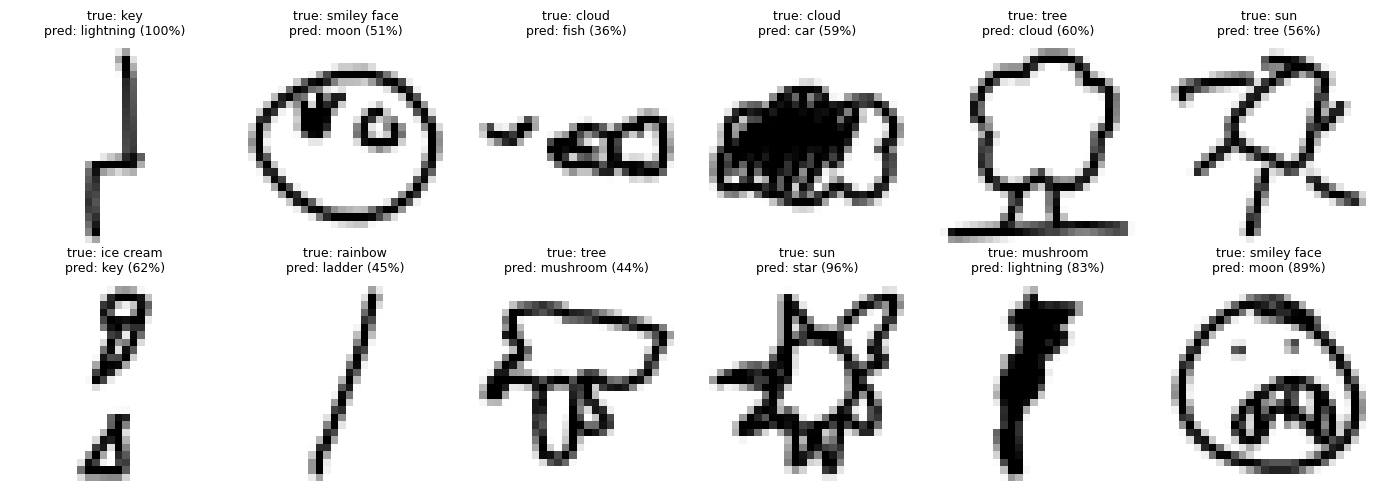

In [11]:
# ============================================================
# STEP 8 · Show 12 random mistakes, with true label and prediction
# ============================================================
wrong = np.where(y_pred != y_test)[0]
print(len(wrong), "wrong out of", len(y_test))

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax, i in zip(axes.flat, np.random.choice(wrong, 12, replace=False)):
    ax.imshow(X_test[i].squeeze(), cmap="gray_r")
    ax.set_title(f"true: {CLASSES[y_test[i]]}\npred: {CLASSES[y_pred[i]]} ({conf[i]*100:.0f}%)", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:12px 16px;border-radius:6px;margin:10px 0"><b style='color:#E8A020'>What we found:</b><br><b>Label noise.</b> Many "mistakes" are not the model's fault. One "house" was actually a <b>written word</b>. Others were stick figures or random scribbles.
The label only says which word the person was <i>asked</i> to draw, not what they actually drew.<br><br>
This explains why accuracy stops around 97%: most remaining errors are bad data, not a weak model.<br>
<b>Possible improvement:</b> Quick, Draw!'s <code>simplified .ndjson</code> files have a <code>recognized</code> field. Keeping only <code>recognized: true</code> drawings would remove most of this noise.</div>

## Step 9: Choose the "I'm not sure" threshold
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; <b style='color:#6FAF22'>[ Evaluate ]</b> &rarr; Save &rarr; Air Drawing</div>

<div style="background:#EFF6FF;border-left:5px solid #15294D;padding:12px 16px;border-radius:6px;margin:10px 0">The model always picks one of the 20 classes, even for a scribble. So in the game, if the top probability is below a <b>threshold</b>, the AI says <i>"Hmm, I'm not sure..."</i> instead of a wrong answer.<br>
Higher threshold = answers less often, but is more accurate when it does.</div>

In [12]:
# ============================================================
# STEP 9 · How often does the model answer, and how accurate is it, at each threshold?
# ============================================================
# (probs, y_pred and conf come from Step 7)
for t in [0.5, 0.6, 0.7, 0.8, 0.9]:
    answered = conf >= t                                         # drawings where the model is confident enough
    acc = (y_pred[answered] == y_test[answered]).mean()          # accuracy on those drawings only
    print(f"threshold {t}: answers {answered.mean() * 100:5.1f}% | accuracy when answering {acc * 100:5.1f}%")

threshold 0.5: answers  98.1% | accuracy when answering  95.3%
threshold 0.6: answers  96.7% | accuracy when answering  96.1%
threshold 0.7: answers  95.1% | accuracy when answering  96.9%
threshold 0.8: answers  93.4% | accuracy when answering  97.6%
threshold 0.9: answers  91.0% | accuracy when answering  98.3%


<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:12px 16px;border-radius:6px;margin:10px 0"><b style='color:#E8A020'>What we found (version 1, 5 classes):</b><br><table>
<tr><th>Threshold</th><th>Answers</th><th>Accuracy when answering</th></tr>
<tr><td>0.5</td><td>99.5%</td><td>97.4%</td></tr>
<tr><td>0.6</td><td>98.8%</td><td>97.8%</td></tr>
<tr><td><b>0.7 ✅</b></td><td><b>98.0%</b></td><td><b>98.2%</b></td></tr>
<tr><td>0.8</td><td>97.4%</td><td>98.5%</td></tr>
<tr><td>0.9</td><td>96.4%</td><td>98.9%</td></tr>
</table>
We chose <b>0.7</b>: it still answers almost every drawing, and is right 98.2% of the time.
Air drawings will be shakier, so the model will be less confident on them. We may lower it to 0.5 or 0.6 after testing with the camera.</div>

## Step 10: Save the model
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; <b style='color:#6FAF22'>[ Save ]</b> &rarr; Air Drawing</div>

Saves `doodle_model.keras` and `classes.txt` to `MyDrive/air_pictionary`. Step 11 loads them from there, so we never need to retrain.

In [13]:
# ============================================================
# STEP 10 · Save the model and the class names to Google Drive
# ============================================================
SAVE_DIR = "/content/drive/MyDrive/air_pictionary"
model.save(f"{SAVE_DIR}/doodle_model.keras")                     # architecture + learned weights in one file
with open(f"{SAVE_DIR}/classes.txt", "w") as f:
    f.write("\n".join(CLASSES))                                  # one class name per line, same order as the labels
print("Saved model and classes to", SAVE_DIR)

Saved model and classes to /content/drive/MyDrive/air_pictionary


---
# PART 2: Draw in the Air

## Step 11: Live air drawing + AI guesses
<div style='background:#F3F6FA;padding:8px 14px;border-radius:6px;font-family:monospace;font-size:13px'>Pipeline: Data &rarr; Explore &rarr; Prepare &rarr; CNN &rarr; Train &rarr; Evaluate &rarr; Save &rarr; <b style='color:#6FAF22'>[ Air Drawing ]</b></div>

<div style="background:#F0FDFA;border-left:5px solid #0D9488;padding:12px 16px;border-radius:6px;margin:10px 0"><b>Why the camera runs in the browser:</b> Colab runs on Google's servers, so Python can't open your webcam directly.
Sending every frame to the server would be slow (2–5 FPS). So the <b>browser</b> does the camera and hand tracking live, and only sends the <b>finished drawing</b> to Python for the guess.
<pre style="background:white;padding:10px;border-radius:6px;margin:8px 0">
BROWSER (JavaScript, live)                          PYTHON (Colab server)
Camera → MediaPipe Hands → pinch? → draw line  ──►  crop → square → 28×28 → CNN → top 3 guesses
                         21 hand points               (every 0.6 s, only if the drawing changed)
</pre></div>

**How the drawing works**

| Gesture | Action |
|---|---|
| 🤏 Pinch (thumb + index touching) | **Draw** (green dot) |
| ✋ Fingers apart | **Pen up**, move without drawing (red dot) |
| 🖐️ Open palm, held | **Clear** the drawing |

**Problems we hit, and how we fixed them**

| Problem | Cause | Fix |
|---|---|---|
| Line broke into dashes and dots | "Only index finger up" was misread when the hand was tilted | Switched to **pinch to draw** (much easier to detect), with **hysteresis**: start at gap < 0.30, stop only at gap > 0.45 |
| One bad frame cut the line | Tracker errors for a single frame | **Debouncing**: the pen only changes state after 2 steady frames (start) or 6 (stop) |
| Line jumped to another finger | Tracker briefly mixed up fingers | **Jump guard**: skip points that jump more than 120 px; pen = midpoint of thumb and index |
| Line broke when the hand disappeared briefly | Hand lost for a few frames | Keep the line alive for up to 8 missing frames |
| Jagged lines | Fingertip shakes | **Smoothing**: new point = 0.6 × old + 0.4 × new |
| Drawing too thin at 28×28 | Big drawing shrunk ~10× | Line width 18 px (Quick, Draw! strokes are ~2 px at 28×28) |

**Making the drawing look like Quick, Draw!** (`preprocess()`): read the canvas **alpha channel** (255 where you drew, 0 elsewhere = white stroke on black, like the dataset) → crop to the drawing → pad to a centered square → add a 10% margin → resize to 28 × 28.

<div style="background:#FFF7ED;border-left:5px solid #E8A020;padding:12px 16px;border-radius:6px;margin:10px 0"><b>To run:</b> use <b>Chrome</b>, allow Drive and camera access, use good light, and keep your whole hand (with the wrist) in the frame.<br>
<b>What you will see:</b> the camera with your drawing, the AI's guess and top 3 on the right, and a small preview of <b>what the model sees</b> (useful to understand wrong guesses).</div>

In [ ]:
# ===== Air Pictionary: draw in the air, the AI guesses live =====
# Part 1 (Python): load the model and register the "guess" function
import numpy as np, base64, io, cv2
import tensorflow as tf
from PIL import Image
from google.colab import drive, output
from IPython.display import HTML, JSON, display

drive.mount("/content/drive")
SAVE_DIR = "/content/drive/MyDrive/air_pictionary"
model = tf.keras.models.load_model(f"{SAVE_DIR}/doodle_model.keras")
CLASSES = open(f"{SAVE_DIR}/classes.txt").read().splitlines()
THRESHOLD = 0.7   # lower to 0.5-0.6 if the AI says "not sure" too often
print("Model loaded:", CLASSES)

def preprocess(data_url):
    """Turn the browser drawing into a 28x28 image like Quick, Draw!"""
    raw = base64.b64decode(data_url.split(",")[1])
    rgba = np.array(Image.open(io.BytesIO(raw)).convert("RGBA"))
    img = rgba[:, :, 3]                      # alpha channel: 255 where ink, 0 where empty
    ys, xs = np.where(img > 0)
    if len(xs) < 20:
        return None
    img = img[ys.min():ys.max()+1, xs.min():xs.max()+1]     # crop to the drawing
    h, w = img.shape
    s = max(h, w)
    sq = np.zeros((s, s), np.uint8)                          # pad to a centered square
    sq[(s-h)//2:(s-h)//2+h, (s-w)//2:(s-w)//2+w] = img
    sq = np.pad(sq, s // 10)                                 # small margin
    return cv2.resize(sq, (28, 28), interpolation=cv2.INTER_AREA)

def guess(data_url):
    small = preprocess(data_url)
    if small is None:
        return JSON({"text": "Draw something...", "details": "", "preview": ""})
    x = small.reshape(1, 28, 28, 1).astype("float32") / 255.0
    p = model(x, training=False).numpy()[0]
    top = p.argsort()[::-1][:3]
    text = f"It's a {CLASSES[top[0]]}!" if p[top[0]] >= THRESHOLD else "Hmm, I'm not sure..."
    details = " · ".join(f"{CLASSES[i]} {p[i]*100:.0f}%" for i in top)
    buf = io.BytesIO()
    Image.fromarray(255 - small).resize((112, 112), Image.NEAREST).save(buf, "PNG")
    preview = "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()
    return JSON({"text": text, "details": details, "preview": preview})

output.register_callback("guess", guess)

# Part 2 (browser): camera + hand tracking + drawing + live guesses
display(HTML('''
<div style="display:flex;gap:16px;align-items:flex-start;font-family:sans-serif">
  <div>
    <canvas id="view" width="640" height="480" style="border-radius:8px;background:#111"></canvas>
    <div id="status" style="font-size:14px;margin-top:6px">Starting...</div>
    <button id="stopBtn">Stop camera</button>
    <button id="clearBtn">Clear drawing</button>
  </div>
  <div style="min-width:220px">
    <div id="guess" style="font-size:26px;font-weight:bold">Draw something...</div>
    <div id="details" style="font-size:15px;margin:8px 0;color:#888"></div>
    <div style="font-size:12px;color:#888">What the model sees:</div>
    <img id="preview" width="112" height="112" style="border:1px solid #555;image-rendering:pixelated;background:#fff">
  </div>
</div>
<video id="cam" autoplay playsinline style="display:none"></video>

<script type="module">
import {FilesetResolver, HandLandmarker} from
  "https://cdn.jsdelivr.net/npm/@mediapipe/tasks-vision@0.10.14/vision_bundle.mjs";

const video     = document.getElementById("cam");
const canvas    = document.getElementById("view");
const ctx       = canvas.getContext("2d");
const status    = document.getElementById("status");
const guessEl   = document.getElementById("guess");
const detailsEl = document.getElementById("details");
const previewEl = document.getElementById("preview");

// Hidden canvas that holds only the drawing
const ink = document.createElement("canvas");
ink.width = canvas.width; ink.height = canvas.height;
const inkCtx = ink.getContext("2d");
inkCtx.lineWidth = 18;              // thick, so it survives shrinking to 28x28
inkCtx.lineCap = "round";
inkCtx.lineJoin = "round";
inkCtx.strokeStyle = "#00e5ff";

let hands, running = true;
let lastX = null, lastY = null;
let palmFrames = 0;
let busy = false, dirty = false;

function clearInk() {
  inkCtx.clearRect(0, 0, ink.width, ink.height);
  dirty = false;
  guessEl.textContent = "Draw something...";
  detailsEl.textContent = "";
  previewEl.removeAttribute("src");
}
document.getElementById("clearBtn").onclick = clearInk;

// Ask Python for a guess, only if the drawing changed and no request is running
async function askModel() {
  if (busy || !dirty || !running) return;
  busy = true; dirty = false;
  try {
    const res = await google.colab.kernel.invokeFunction("guess", [ink.toDataURL("image/png")], {});
    const d = res.data["application/json"];
    guessEl.textContent = d.text;
    detailsEl.textContent = d.details;
    if (d.preview) previewEl.src = d.preview;
  } catch (e) {
    guessEl.textContent = "Error: " + e;
  }
  busy = false;
}
const timer = setInterval(askModel, 600);

document.getElementById("stopBtn").onclick = () => {
  running = false;
  clearInterval(timer);
  if (video.srcObject) video.srcObject.getTracks().forEach(t => t.stop());
  status.textContent = "Camera stopped. Re-run the cell to start again.";
};

function dist(a, b) { return Math.hypot(a.x - b.x, a.y - b.y); }

// A finger is "up" if its tip is farther from the wrist than its middle joint.
// Works even when the hand is tilted.
function fingersUp(lm) {
  const wrist = lm[0];
  return {
    index:  dist(lm[8],  wrist) > dist(lm[6],  wrist) * 1.1,
    middle: dist(lm[12], wrist) > dist(lm[10], wrist) * 1.1,
    ring:   dist(lm[16], wrist) > dist(lm[14], wrist) * 1.1,
    pinky:  dist(lm[20], wrist) > dist(lm[18], wrist) * 1.1,
  };
}

// Pinch detection with hysteresis: start drawing when thumb and index are close,
// stop only when they are clearly apart. Distances are relative to hand size,
// so it works near or far from the camera.
let pinching = false;
function isPinching(lm) {
  const handSize = dist(lm[0], lm[9]);            // wrist -> middle finger base
  const gap = dist(lm[4], lm[8]) / handSize;      // thumb tip <-> index tip
  if (!pinching && gap < 0.30) pinching = true;
  else if (pinching && gap > 0.45) pinching = false;
  return pinching;
}

// Debounce: change the pen state only when the new gesture is stable for a few frames
let penState = "up", candidate = "up", candidateFrames = 0, missingFrames = 0;
function confirmGesture(raw) {
  if (raw === candidate) candidateFrames++;
  else { candidate = raw; candidateFrames = 1; }
  const needed = (raw === "draw") ? 2 : 6;   // start fast, stop only when really sure
  if (candidateFrames >= needed) penState = candidate;
  return penState;
}

// FPS counter
let frames = 0, fps = 0, fpsTime = performance.now();
let jumpFrames = 0;

function loop() {
  if (!running) return;

  frames++;
  if (performance.now() - fpsTime > 1000) { fps = frames; frames = 0; fpsTime = performance.now(); }

  ctx.save();
  ctx.translate(canvas.width, 0);
  ctx.scale(-1, 1);
  ctx.drawImage(video, 0, 0, canvas.width, canvas.height);
  ctx.restore();

  const result = hands.detectForVideo(video, performance.now());

  if (result.landmarks.length > 0) {
    missingFrames = 0;
    const lm = result.landmarks[0];
    const up = fingersUp(lm);

    const pinch = isPinching(lm);
    let raw = "up";
    if (pinch) raw = "draw";
    else if (up.index && up.middle && up.ring && up.pinky) raw = "palm";
    const state = confirmGesture(raw);

    // Pen position = midpoint between thumb tip and index tip (more stable than one point)
    let x = (1 - (lm[4].x + lm[8].x) / 2) * canvas.width;
    let y = ((lm[4].y + lm[8].y) / 2) * canvas.height;

    // Jump guard: if the point suddenly jumps far (tracker glitch), skip a few frames
    if (state === "draw" && lastX !== null && Math.hypot(x - lastX, y - lastY) > 120) {
      jumpFrames++;
      if (jumpFrames <= 5) {
        ctx.drawImage(ink, 0, 0);
        requestAnimationFrame(loop);
        return;
      }
      lastX = null;                      // the jump is real: start a new line here
    }
    jumpFrames = 0;

    if (state === "palm") {
      palmFrames++;
      status.textContent = `🖐️ Hold to clear... | ${fps} FPS`;
      if (palmFrames > 10) { clearInk(); status.textContent = "Cleared!"; }
      lastX = null;
    } else if (state === "draw") {
      palmFrames = 0;
      if (lastX !== null) {
        x = 0.6 * lastX + 0.4 * x;          // smoothing
        y = 0.6 * lastY + 0.4 * y;
        inkCtx.beginPath();
        inkCtx.moveTo(lastX, lastY);
        inkCtx.lineTo(x, y);
        inkCtx.stroke();
        dirty = true;
      }
      lastX = x; lastY = y;
      status.textContent = `🤏 Drawing | ${fps} FPS`;
    } else {
      palmFrames = 0;
      lastX = null;
      status.textContent = `✋ Pen up (pinch to draw) | ${fps} FPS`;
    }

    ctx.beginPath();
    ctx.arc(x, y, 10, 0, 2 * Math.PI);
    ctx.fillStyle = (state === "draw") ? "#00ff66" : "red";
    ctx.fill();
  } else {
    // Hand lost: keep the line alive for a few frames before lifting the pen
    missingFrames++;
    if (missingFrames > 8) {
      lastX = null;
      penState = "up"; candidate = "up";
    }
    palmFrames = 0;
    status.textContent = `No hand | ${fps} FPS`;
  }

  ctx.drawImage(ink, 0, 0);
  requestAnimationFrame(loop);
}

try {
  status.textContent = "1/3 Loading MediaPipe files...";
  const vision = await FilesetResolver.forVisionTasks(
    "https://cdn.jsdelivr.net/npm/@mediapipe/tasks-vision@0.10.14/wasm");
  status.textContent = "2/3 Loading hand model...";
  // Try the faster GPU mode first, fall back to CPU if the browser doesn't support it
  const makeHands = (delegate) => HandLandmarker.createFromOptions(vision, {
    baseOptions: {
      modelAssetPath: "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task",
      delegate
    },
    runningMode: "VIDEO",
    numHands: 1,
    minHandDetectionConfidence: 0.6,
    minTrackingConfidence: 0.6
  });
  try { hands = await makeHands("GPU"); } catch (e) { hands = await makeHands("CPU"); }
  status.textContent = "3/3 Starting camera...";
  video.srcObject = await navigator.mediaDevices.getUserMedia({video: {width: 640, height: 480}});
  await video.play();
  status.textContent = "Show your hand to the camera";
  loop();
} catch (err) {
  status.textContent = "❌ Error: " + err;
  status.style.color = "red";
}
</script>
'''))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded: ['sun', 'fish', 'house', 'star', 'umbrella']


In [16]:
# STEP 12 · Export the model for the website (TensorFlow.js format, no extra libraries)
import json, os, numpy as np, tensorflow as tf
from tensorflow.keras import layers

SAVE_DIR = "/content/drive/MyDrive/air_pictionary"
trained = tf.keras.models.load_model(f"{SAVE_DIR}/doodle_model.keras")
CLASSES = open(f"{SAVE_DIR}/classes.txt").read().splitlines()

OUT = "tfjs_model"
os.makedirs(OUT, exist_ok=True)
topology = [{"class_name": "InputLayer", "config": {
    "batch_input_shape": [None, 28, 28, 1], "dtype": "float32", "sparse": False, "name": "input"}}]
manifest, blobs = [], []

for l in trained.layers:   # augmentation + dropout are skipped (off when predicting anyway)
    base = {"name": l.name, "trainable": True, "dtype": "float32"}
    if isinstance(l, layers.Conv2D):
        topology.append({"class_name": "Conv2D", "config": {**base, "filters": l.filters,
            "kernel_size": list(l.kernel_size), "strides": [1, 1], "padding": "same",
            "data_format": "channels_last", "dilation_rate": [1, 1], "activation": "relu", "use_bias": True}})
    elif isinstance(l, layers.MaxPooling2D):
        topology.append({"class_name": "MaxPooling2D", "config": {**base, "pool_size": [2, 2],
            "padding": "valid", "strides": [2, 2], "data_format": "channels_last"}})
    elif isinstance(l, layers.Flatten):
        topology.append({"class_name": "Flatten", "config": {**base, "data_format": "channels_last"}})
    elif isinstance(l, layers.Dense):
        topology.append({"class_name": "Dense", "config": {**base, "units": l.units,
            "activation": l.activation.__name__, "use_bias": True}})
    else:
        print("skipped:", l.name)
        continue
    for wname, w in zip(["kernel", "bias"], l.get_weights()):
        w = w.astype(np.float32)
        manifest.append({"name": f"{l.name}/{wname}", "shape": list(w.shape), "dtype": "float32"})
        blobs.append(w.tobytes())

open(f"{OUT}/weights.bin", "wb").write(b"".join(blobs))
json.dump({"format": "layers-model", "generatedBy": "keras", "convertedBy": "manual",
           "modelTopology": {"class_name": "Sequential", "keras_version": "2.15.0", "backend": "tensorflow",
                             "config": {"name": "doodle", "layers": topology}},
           "weightsManifest": [{"paths": ["weights.bin"], "weights": manifest}]},
          open(f"{OUT}/model.json", "w"))
json.dump(CLASSES, open(f"{OUT}/classes.json", "w"))

print("Classes:", len(CLASSES))
!ls -la tfjs_model
!zip -r tfjs_model.zip tfjs_model
from google.colab import files
files.download("tfjs_model.zip")

skipped: random_rotation
skipped: random_translation
skipped: random_zoom
skipped: dropout
Classes: 20
total 968
drwxr-xr-x 2 root root   4096 Oct  8 02:19 .
drwxr-xr-x 1 root root   4096 Oct  8 02:19 ..
-rw-r--r-- 1 root root    192 Oct  8 02:19 classes.json
-rw-r--r-- 1 root root   2916 Oct  8 02:19 model.json
-rw-r--r-- 1 root root 971344 Oct  8 02:19 weights.bin
  adding: tfjs_model/ (stored 0%)
  adding: tfjs_model/classes.json (deflated 39%)
  adding: tfjs_model/weights.bin (deflated 7%)
  adding: tfjs_model/model.json (deflated 80%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>